# Devoir de SN de Machine Learning
Licence 3 - MTQ

## Importation des librairies

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Chargement du dataset

In [19]:
# Charger le fichier CSV
df = pd.read_csv("dataset_financier.csv")

# Aperçu
df.head()

,bilan_financier,actifs,revenu,depenses,taux_interet,flux_tresorerie,capital,agence,banque,lieu
0,57450.712295,29795.488056,2459.857380,546.096221,4.850180,9549.649146,36581.956747,Agence_Centre,Société Générale,Bafoussam
1,47926.035482,26472.435780,2884.385063,1069.807495,0.854030,6207.981496,38725.670920,Agence_Centre,UBA,Douala
2,59715.328072,20417.412589,2366.064063,1293.197233,9.724614,11458.554375,77179.593209,Agence_Sud,UBA,Bafoussam
3,72845.447846,15471.442556,2753.630776,2443.843829,5.180104,4151.884734,36901.898344,Agence_Centre,UBA,Douala
4,46487.699379,24887.563195,1485.108266,1778.276562,6.141862,3848.927628,46121.492335,Agence_Centre,Ecobank,Bafoussam


## Informations générales

In [20]:
df.shape

(1000, 10)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bilan_financier  1000 non-null   float64
 1   actifs           1000 non-null   float64
 2   revenu           1000 non-null   float64
 3   depenses         1000 non-null   float64
 4   taux_interet     1000 non-null   float64
 5   flux_tresorerie  1000 non-null   float64
 6   capital          1000 non-null   float64
 7   agence           1000 non-null   str    
 8   banque           1000 non-null   str    
 9   lieu             1000 non-null   str    
dtypes: float64(7), str(3)
memory usage: 104.5 KB


In [22]:
#nom des colonnes
df.columns

Index(['bilan_financier', 'actifs', 'revenu', 'depenses', 'taux_interet',
       'flux_tresorerie', 'capital', 'agence', 'banque', 'lieu'],
      dtype='str')

In [23]:
# Types des colonnes
df.dtypes 

bilan_financier    float64
actifs             float64
revenu             float64
depenses           float64
taux_interet       float64
flux_tresorerie    float64
capital            float64
agence                 str
banque                 str
lieu                   str
dtype: object

## Nettoyage des données

In [24]:
# Supprimer doublons
df = df.drop_duplicates()

# Vérifier valeurs manquantes
df.isnull().sum()

bilan_financier    0
actifs             0
revenu             0
depenses           0
taux_interet       0
flux_tresorerie    0
capital            0
agence             0
banque             0
lieu               0
dtype: int64

In [25]:
df.shape

(1000, 10)

### Commentaire :
Donc pas de doublons dans ce jeu de données. Et aucune valeur manquante non plus. Ce qui nous facilite son exploitation.

## Détection et traitement des outliers

### Commentaire :
Le traitement des valeurs aberrantes doit être appris sur l’échantillon d’entraînement afin d’éviter toute fuite d’information vers l’échantillon de test et garantir une évaluation objective du modèle. D'où nous ferons plus bas, après avoir séparer les données Test et Train, pour écarter toute possibilité de data leakage.

## Analyse exploratoire (EDA)

In [26]:
# Statistiques descriptives (variables numériques)
df.describe()

,bilan_financier,actifs,revenu,depenses,taux_interet,flux_tresorerie,capital
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,50289.980837,20495.853661,3004.667372,1490.640391,4.991526,9910.662587,39582.085591
std,14688.239073,6982.180641,786.763425,513.566263,2.901605,2963.913307,12364.166625
min,1380.989899,-582.720443,584.390275,35.275655,0.061838,1500.909130,5205.833442
25%,40286.145418,15756.308177,2481.600309,1131.289773,2.457276,7978.062358,30915.352716
50%,50379.509184,20441.539926,2999.799388,1500.092287,4.914739,9885.273463,39480.431990
75%,59719.158132,25102.175239,3528.732251,1833.472705,7.538136,11879.381786,48259.573668
max,107790.972360,42351.752975,6140.990165,3121.546485,9.993503,19338.730603,77179.593209


In [27]:
# Statistiques descriptives (variables catégorielles)
df.describe(include="str")

,agence,banque,lieu
count,1000,1000,1000
unique,3,4,4
top,Agence_Sud,UBA,Bafoussam
freq,342,260,266


In [28]:
# Répartition d'une colonne catégorielle : Banque
df["banque"].value_counts()

banque
UBA                 260
Ecobank             251
BGFI                251
Société Générale    238
Name: count, dtype: int64

In [29]:
# Répartition de la colonne Lieu
df["lieu"].value_counts()

lieu
Bafoussam    266
Douala       251
Yaoundé      243
Garoua       240
Name: count, dtype: int64

In [30]:
# Répartition de la colonne Agence
df["agence"].value_counts()

agence
Agence_Sud       342
Agence_Nord      335
Agence_Centre    323
Name: count, dtype: int64

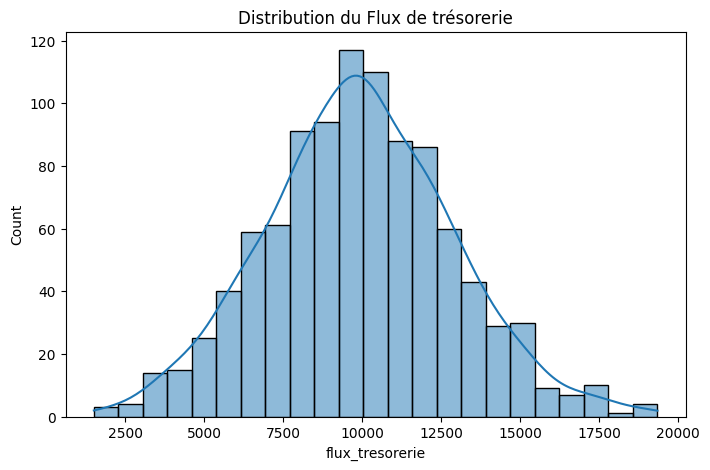

In [31]:
# Distribution de la target

plt.figure(figsize=(8,5))
sns.histplot(df["flux_tresorerie"], kde=True)
plt.title("Distribution du Flux de trésorerie")
plt.show()

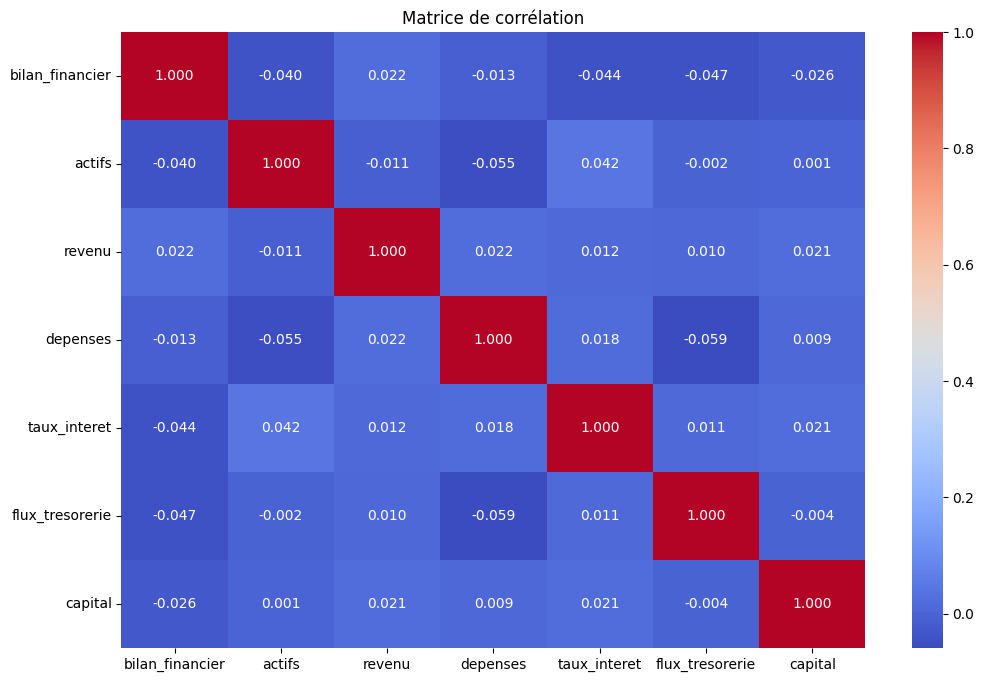

In [32]:
# Matrice de corrélation
# Appliquée uniquement sur les variables numériques. Les variables catégorielles ne pouvant pas être utilisées directement dans df.corr()

plt.figure(figsize=(12,8))

# Sélection des colonnes numériques seulement
df_num = df.select_dtypes(include=['int64', 'float64'])

# Matrice de corrélation
corr_matrix = df_num.corr()

# Heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".3f")

plt.title("Matrice de corrélation")
plt.show()

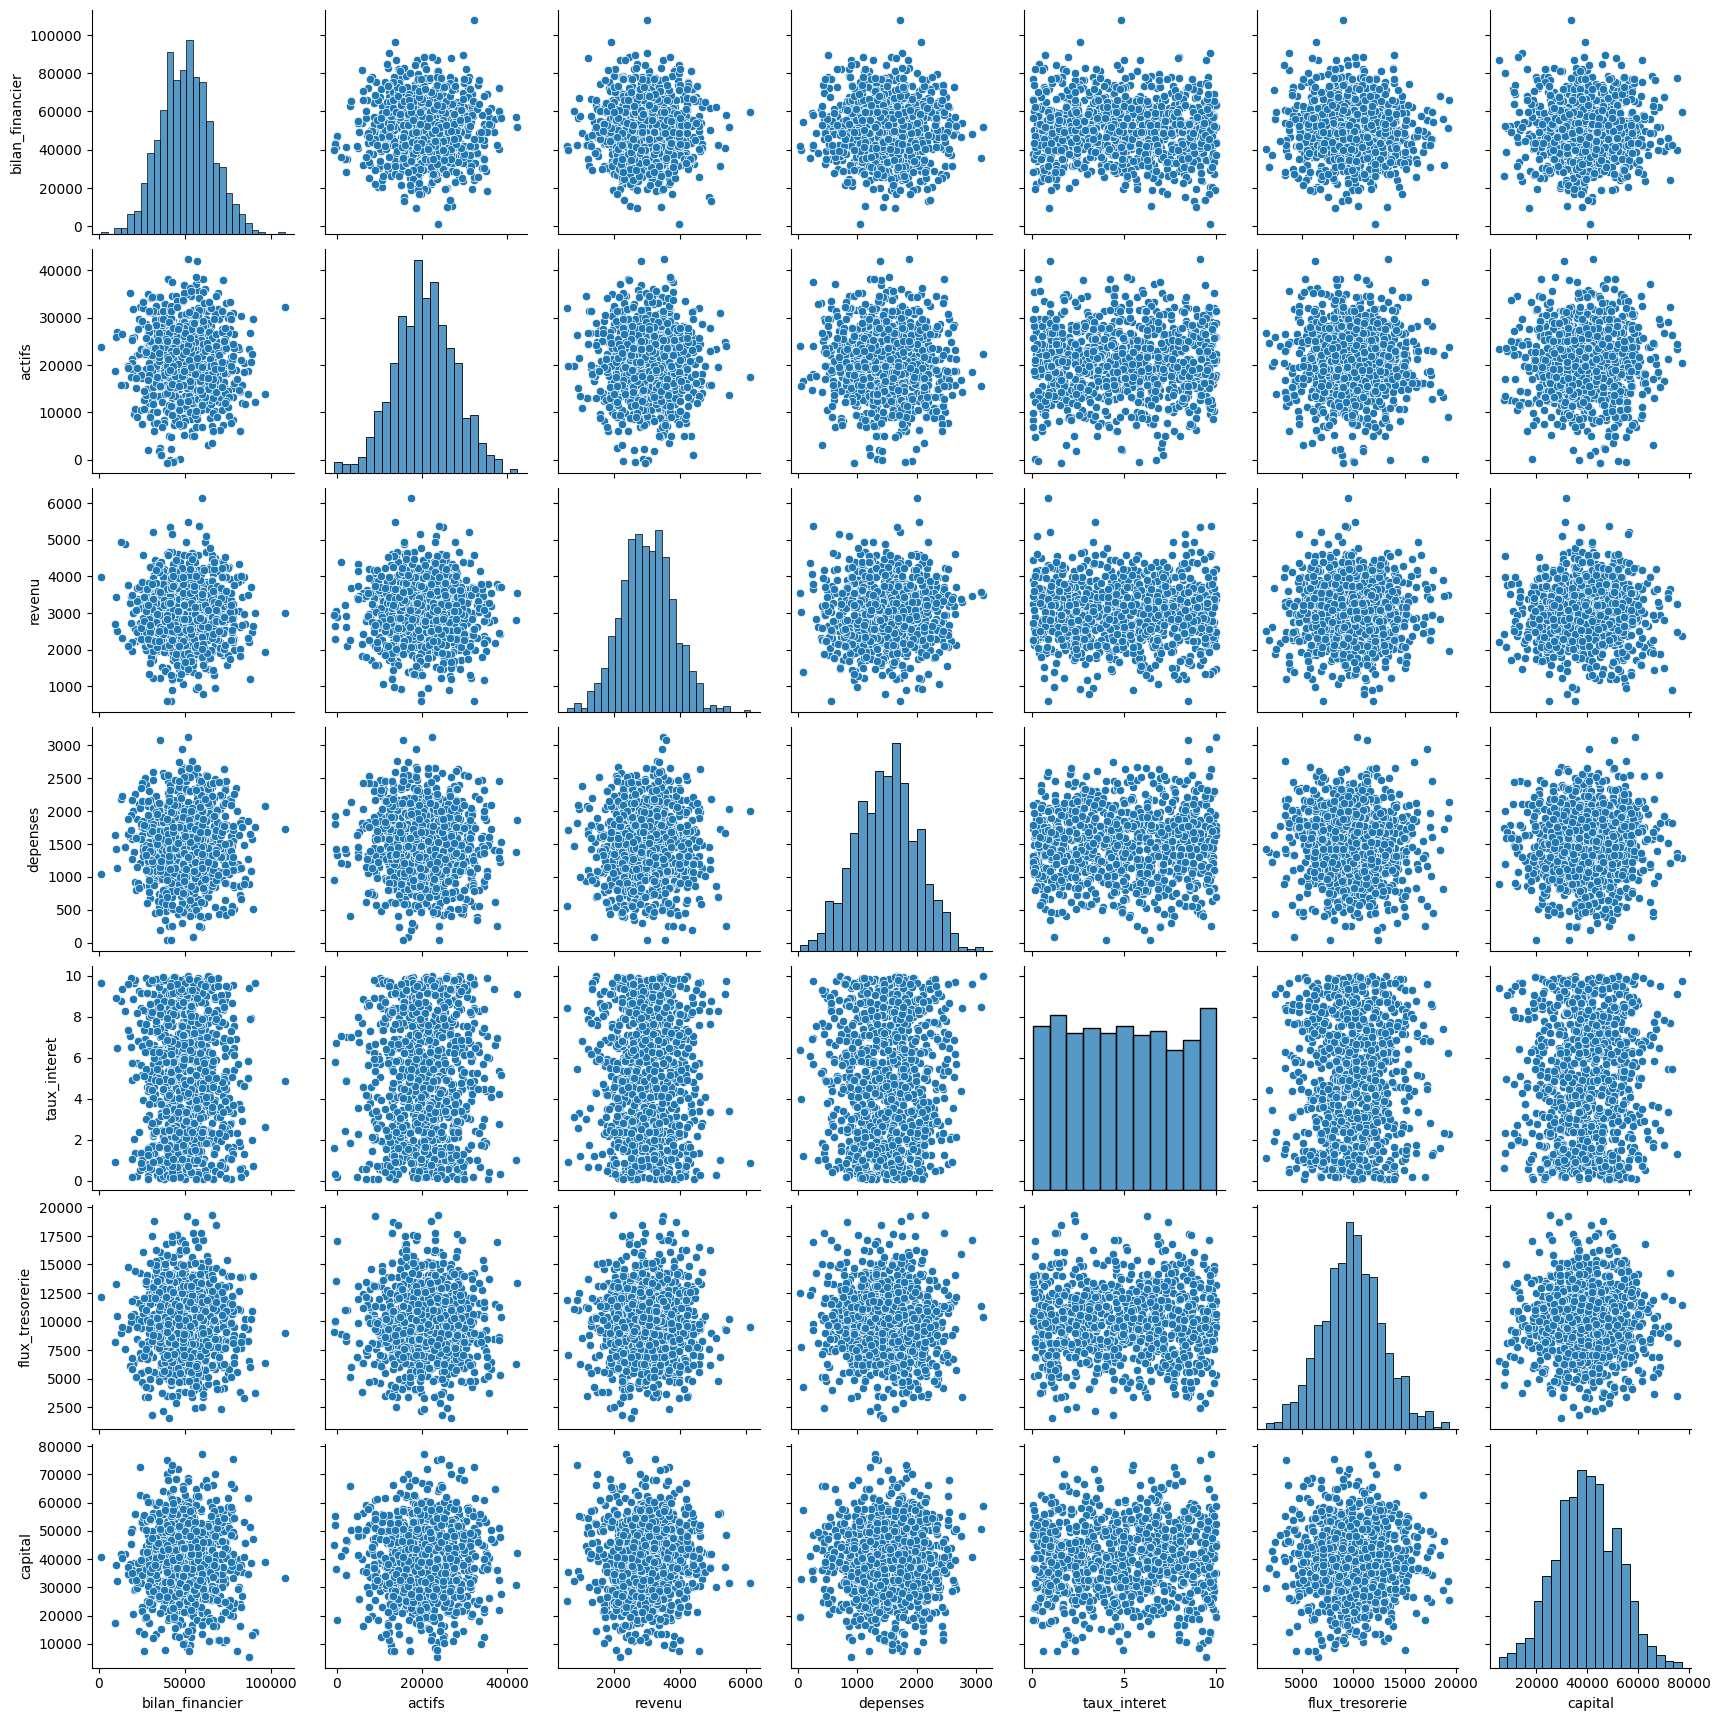

In [33]:
#
sns.pairplot(data=df)

### Commentaire :
De prime abord, nous constatons que nos variables quantitatives sont très peu correlées entre elles. Les plus faiblement liées étant les dépenses et les flux de trésorerie, suivies du montant des dépenses et celui des actifs. Et pour les plus fortement liées, il s'agit des actifs et taux d'intérêt.

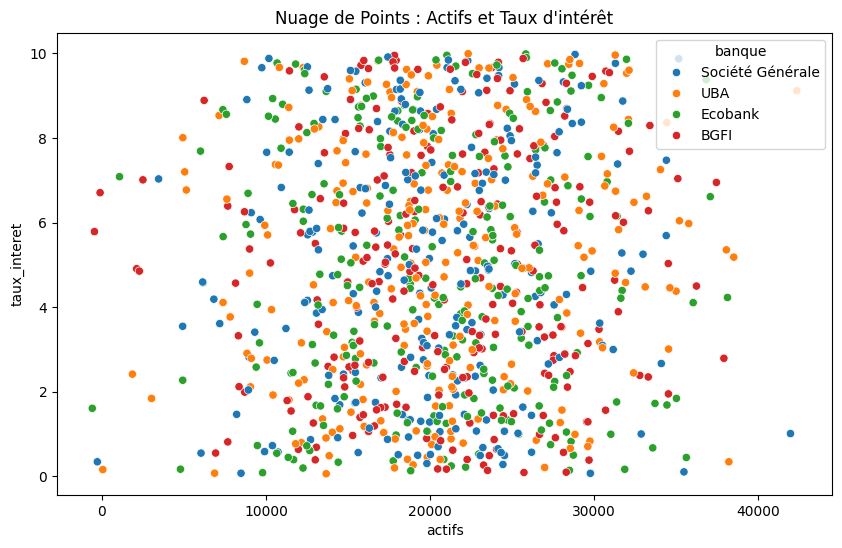

In [34]:
# Zoom sur le nuage de points des variables les plus fortement correlées

plt.figure(figsize=(10,6))
sns.scatterplot(x="actifs", y="taux_interet", data=df, hue="banque")
plt.title("Nuage de Points : Actifs et Taux d'intérêt")
plt.show()

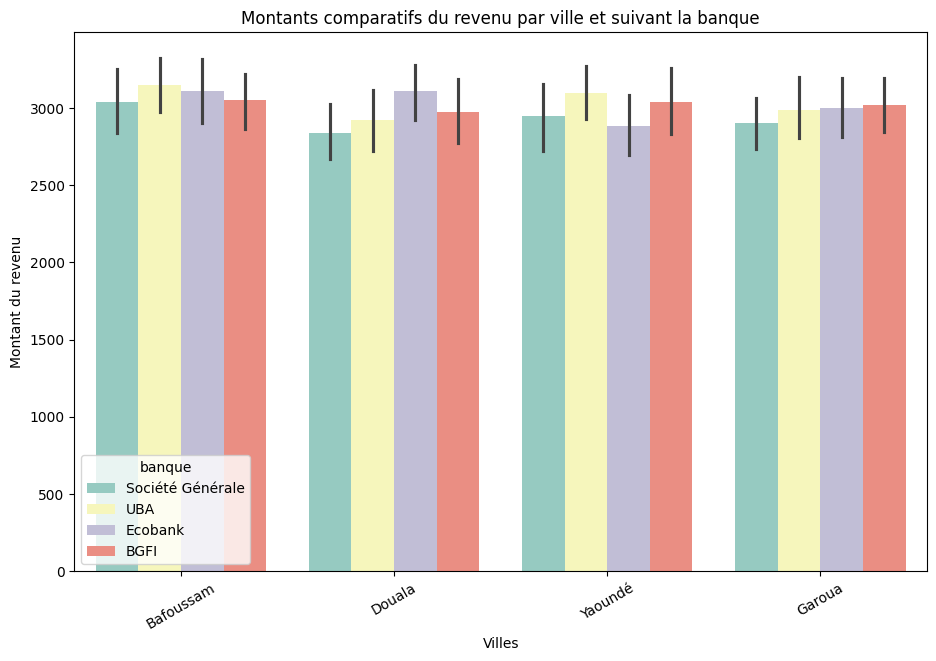

In [35]:
# Graphique comparatif (diagramme à barres)

plt.figure(figsize=(11,7))
sns.barplot(x="lieu", y="revenu", data=df, hue="banque", palette="Set3")
plt.title("Montants comparatifs du revenu par ville et suivant la banque")
plt.xlabel("Villes")
plt.ylabel("Montant du revenu")
plt.xticks(rotation=30)
plt.show()

## REGRESSION (Random Forest Model)

## Préparation des variables

In [36]:
# Variable cible
y = df[["flux_tresorerie"]]

# Variables explicatives
X = df.drop(columns=["flux_tresorerie"])

# Encodage des variables catégorielles -- One-hot encoding
# (càd convertir chaque modalité en colonnes 0/1, puis supprimer la 1ère catégorie pour éviter la redondance)
X = pd.get_dummies(X, drop_first=True)

X.head()

,bilan_financier,actifs,revenu,depenses,taux_interet,capital,agence_Agence_Nord,agence_Agence_Sud,banque_Ecobank,banque_Société Générale,banque_UBA,lieu_Douala,lieu_Garoua,lieu_Yaoundé
0,57450.712295,29795.488056,2459.857380,546.096221,4.850180,36581.956747,False,False,False,True,False,False,False,False
1,47926.035482,26472.435780,2884.385063,1069.807495,0.854030,38725.670920,False,False,False,False,True,True,False,False
2,59715.328072,20417.412589,2366.064063,1293.197233,9.724614,77179.593209,False,True,False,False,True,False,False,False
3,72845.447846,15471.442556,2753.630776,2443.843829,5.180104,36901.898344,False,False,False,False,True,True,False,False
4,46487.699379,24887.563195,1485.108266,1778.276562,6.141862,46121.492335,False,False,True,False,False,False,False,False


In [37]:
X.shape

(1000, 14)

In [38]:
type(y)

pandas.DataFrame

In [39]:
y

,flux_tresorerie
0,9549.649146
1,6207.981496
2,11458.554375
3,4151.884734
4,3848.927628
...,...
995,10283.863134
996,5123.367899
997,2480.285288
998,10892.386159


## Train / Test split

In [40]:
# Division des données Training et données Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [41]:
# Features Scaling  ( pour standardiser les variables explicatives avant l’entraînement du modèle )
        # Permet de transformer chaque variable pour avoir : moyenne = 0 et écart-type = 1 ;
        # bien que souvent inutile pour les modèles de type Arbre, car ne dépendant pas des distances.

sc = StandardScaler()

X_train = sc.fit_transform(X_train)  ## apprendre et transformer le training set
X_test = sc.transform(X_test)        ## ici, on ne recalcule pas les stats sur le test, on applique celles 
                                        # du train, afin d'éviter toute fuite de données (data_leakage)
                                        #  et garantir une évaluation impartiale du modèle.

In [42]:
type(X_train)

numpy.ndarray

In [43]:
# Reconversion en dataframes (devenus array suite à la précédente transformation de sklearn)

X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

In [44]:
X_train

,bilan_financier,actifs,revenu,depenses,taux_interet,capital,agence_Agence_Nord,agence_Agence_Sud,banque_Ecobank,banque_Société Générale,banque_UBA,lieu_Douala,lieu_Garoua,lieu_Yaoundé
0,1.470612,-0.414114,-1.500616,-1.909313,0.611434,-1.523484,1.344987,-0.726288,1.766601,-0.564005,-0.590695,1.722862,-0.566059,-0.578377
1,-2.134993,0.671098,0.608184,-0.437087,0.256380,-0.363948,-0.743502,1.376863,-0.566059,-0.564005,1.692920,-0.580429,-0.566059,-0.578377
2,-1.744918,1.262316,0.174573,1.309481,0.068766,-1.451437,-0.743502,1.376863,-0.566059,-0.564005,1.692920,1.722862,-0.566059,-0.578377
3,1.372538,-0.178829,0.511452,-0.360109,1.404154,-1.656858,-0.743502,-0.726288,-0.566059,1.773033,-0.590695,-0.580429,1.766601,-0.578377
4,-0.160721,1.121071,0.201208,2.262391,0.648562,-0.608715,-0.743502,1.376863,1.766601,-0.564005,-0.590695,1.722862,-0.566059,-0.578377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,1.888877,0.528359,-0.940701,-1.246009,0.138483,-0.023841,-0.743502,1.376863,-0.566059,-0.564005,-0.590695,1.722862,-0.566059,-0.578377
746,1.433096,1.011026,0.345928,-0.185520,-1.393203,0.218698,1.344987,-0.726288,-0.566059,-0.564005,-0.590695,-0.580429,-0.566059,1.728977
747,0.164496,-0.225171,-0.559951,-0.418077,-0.855404,-0.483998,-0.743502,-0.726288,-0.566059,-0.564005,-0.590695,-0.580429,-0.566059,1.728977
748,0.032521,0.195316,-0.393299,0.901771,-0.600068,-0.567881,1.344987,-0.726288,1.766601,-0.564005,-0.590695,-0.580429,1.766601,-0.578377


In [45]:
X_test

,bilan_financier,actifs,revenu,depenses,taux_interet,capital,agence_Agence_Nord,agence_Agence_Sud,banque_Ecobank,banque_Société Générale,banque_UBA,lieu_Douala,lieu_Garoua,lieu_Yaoundé
0,0.513249,0.497418,3.064505,-2.427219,1.626202,0.738356,1.344987,-0.726288,1.766601,-0.564005,-0.590695,-0.580429,-0.566059,-0.578377
1,0.963312,-1.166722,0.340426,-0.130102,-0.280218,0.489997,-0.743502,1.376863,-0.566059,1.773033,-0.590695,-0.580429,-0.566059,-0.578377
2,-1.929226,-0.195054,0.415181,-0.676666,1.106366,-0.620231,-0.743502,-0.726288,1.766601,-0.564005,-0.590695,1.722862,-0.566059,-0.578377
3,-0.631059,1.238779,-1.224119,-0.327616,0.540929,-1.415655,-0.743502,-0.726288,1.766601,-0.564005,-0.590695,-0.580429,-0.566059,-0.578377
4,-1.195498,0.471327,1.572734,-0.369974,0.784874,1.577314,1.344987,-0.726288,-0.566059,-0.564005,-0.590695,-0.580429,-0.566059,1.728977
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,-0.119648,1.840847,0.609285,-1.813593,1.136233,1.071510,1.344987,-0.726288,-0.566059,-0.564005,-0.590695,-0.580429,-0.566059,1.728977
246,-1.255546,0.220357,0.569519,0.485939,-0.908268,0.548830,-0.743502,1.376863,-0.566059,1.773033,-0.590695,-0.580429,1.766601,-0.578377
247,-0.349695,-0.521513,1.228428,0.571070,-1.256280,0.246074,-0.743502,1.376863,-0.566059,-0.564005,1.692920,1.722862,-0.566059,-0.578377
248,-0.871627,0.295529,-0.579867,-0.156168,-1.075519,-0.747884,1.344987,-0.726288,1.766601,-0.564005,-0.590695,-0.580429,-0.566059,-0.578377


## Traitement des outliers dans le training set X_train

#### Sélection des variables numériques

In [46]:
X_train.columns

Index(['bilan_financier', 'actifs', 'revenu', 'depenses', 'taux_interet',
       'capital', 'agence_Agence_Nord', 'agence_Agence_Sud', 'banque_Ecobank',
       'banque_Société Générale', 'banque_UBA', 'lieu_Douala', 'lieu_Garoua',
       'lieu_Yaoundé'],
      dtype='str')

In [47]:
cols_num = [
    "bilan_financier",
    "actifs",
    "revenu",
    "depenses",
    "taux_interet",
    "capital"
]
cols_num

['bilan_financier', 'actifs', 'revenu', 'depenses', 'taux_interet', 'capital']

#### Boxplots de toutes les colonnes numériques (en excluant les catégorielles encodées)

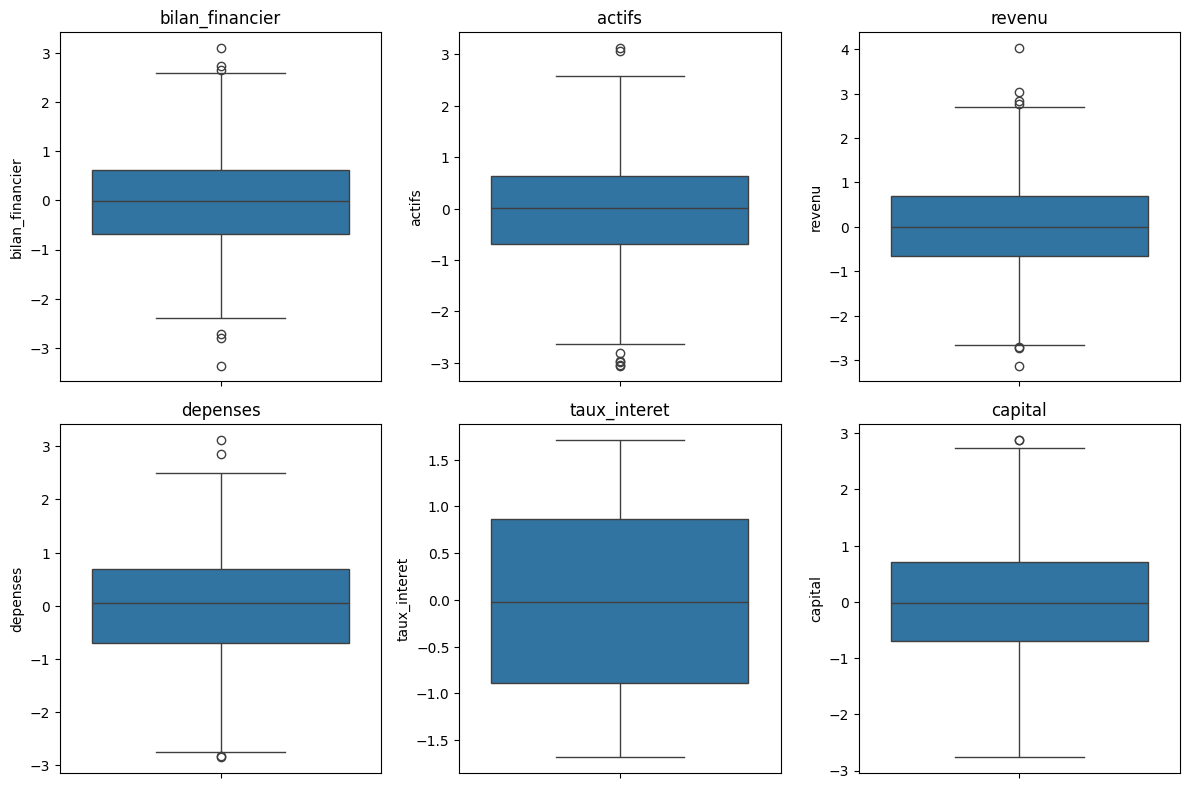

In [48]:
## Boxplots

plt.figure(figsize=(12, 8))

for i, col in enumerate(cols_num, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=X_train[col])
    plt.title(col)

plt.tight_layout()  ## optimiser les espacements automatiquement
plt.show()

#### Détection des outliers par méthode IQR

In [49]:
X_train_num = X_train[cols_num]
X_train_num

,bilan_financier,actifs,revenu,depenses,taux_interet,capital
0,1.470612,-0.414114,-1.500616,-1.909313,0.611434,-1.523484
1,-2.134993,0.671098,0.608184,-0.437087,0.256380,-0.363948
2,-1.744918,1.262316,0.174573,1.309481,0.068766,-1.451437
3,1.372538,-0.178829,0.511452,-0.360109,1.404154,-1.656858
4,-0.160721,1.121071,0.201208,2.262391,0.648562,-0.608715
...,...,...,...,...,...,...
745,1.888877,0.528359,-0.940701,-1.246009,0.138483,-0.023841
746,1.433096,1.011026,0.345928,-0.185520,-1.393203,0.218698
747,0.164496,-0.225171,-0.559951,-0.418077,-0.855404,-0.483998
748,0.032521,0.195316,-0.393299,0.901771,-0.600068,-0.567881


In [50]:
for col in X_train_num.columns:
    
    Q1 = X_train_num[col].quantile(0.25)
    Q3 = X_train_num[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    
    nb_outliers = ((X_train_num[col] < borne_inf) | (X_train_num[col] > borne_sup)).sum()
    
    print(f"{col} : {nb_outliers} outliers détectés")

bilan_financier : 6 outliers détectés
actifs : 7 outliers détectés
revenu : 7 outliers détectés
depenses : 4 outliers détectés
taux_interet : 0 outliers détectés
capital : 2 outliers détectés


#### Winsorisation (remplacement par bornes extrêmes)

In [51]:
## Copie des données par sécurité (garder les données brutes intactes)

X_train_wins = X_train.copy()
X_test_wins = X_test.copy()

In [52]:
for col in cols_num:
    
    # Calcul sur X_train
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR

    # Fit sur le TRAIN
    X_train_wins[col] = np.where(X_train_wins[col] < borne_inf, borne_inf, X_train_wins[col])
    X_train_wins[col] = np.where(X_train_wins[col] > borne_sup, borne_sup, X_train_wins[col])

    # Fit sur le TEST
    X_test_wins[col] = np.where(X_test_wins[col] < borne_inf, borne_inf, X_test_wins[col])
    X_test_wins[col] = np.where(X_test_wins[col] > borne_sup, borne_sup, X_test_wins[col])

### Vérification de la modification des outliers

In [53]:
for col in cols_num:
    
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR

    # AVANT
    nb_inf = (X_train[col] < borne_inf).sum()
    nb_sup = (X_train[col] > borne_sup).sum()

    # APRÈS
    nb_inf_w = (X_train_wins[col] < borne_inf).sum()
    nb_sup_w = (X_train_wins[col] > borne_sup).sum()

    print(f"{col} → AVANT: bas={nb_inf}, haut={nb_sup} | APRÈS: bas={nb_inf_w}, haut={nb_sup_w}")

bilan_financier → AVANT: bas=3, haut=3 | APRÈS: bas=0, haut=0
actifs → AVANT: bas=5, haut=2 | APRÈS: bas=0, haut=0
revenu → AVANT: bas=3, haut=4 | APRÈS: bas=0, haut=0
depenses → AVANT: bas=2, haut=2 | APRÈS: bas=0, haut=0
taux_interet → AVANT: bas=0, haut=0 | APRÈS: bas=0, haut=0
capital → AVANT: bas=0, haut=2 | APRÈS: bas=0, haut=0


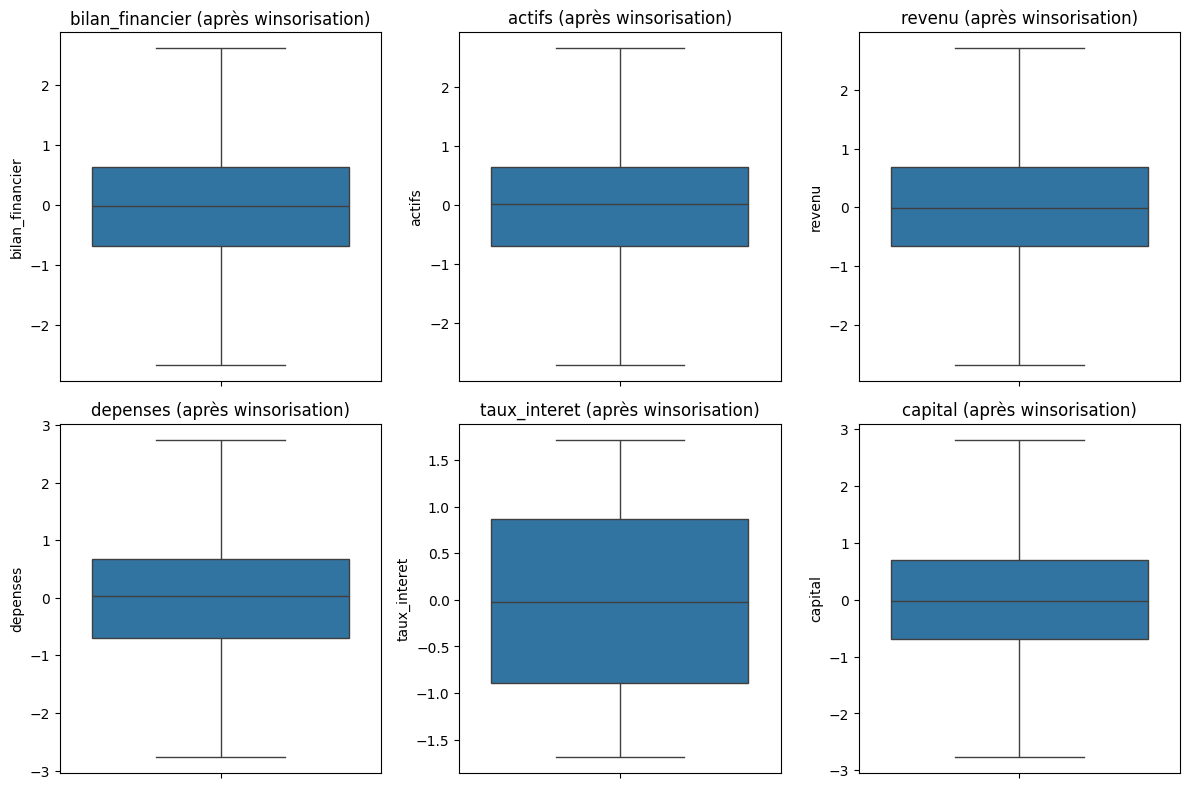

In [54]:
## Boxplots après winsorisation

plt.figure(figsize=(12, 8))

for i, col in enumerate(cols_num, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=X_train_wins[col])
    plt.title(f"{col} (après winsorisation)")

plt.tight_layout()
plt.show()

#### Comparaison des dimensions

In [55]:
print("Dataset original :", X_train.shape)
print("Après winsorisation :", X_train_wins.shape)

Dataset original : (750, 14)
Après winsorisation : (750, 14)


### Commentaire :
Une analyse des valeurs aberrantes a été réalisée à l’aide de la méthode IQR. Étant donné la proportion modérée d’outliers et la taille de l’échantillon (1000 observations), une approche par winsorisation a été privilégiée afin de limiter l’impact de ces valeurs aberrantes, tout en conservant un maximum d’information.
Ces valeurs aberrantes ont été imputées à partir des statistiques calculées exclusivement sur l’échantillon d’entraînement afin d’éviter toute fuite d’information vers l’échantillon de test et garantir une évaluation rigoureuse du modèle.

## Entraînement de notre modèle Random Forest

In [56]:
## Modélisation pour regression avec Random Forest 

rf = RandomForestRegressor(random_state=42)

In [57]:
## Définition des hyperparamètres à tester

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"]
}

In [58]:
## Recherche des hyperperamètres optimaux

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                 # 5 semi-échantillons pour la cross-validation
    scoring="r2",         # métrique principale
    n_jobs=-1,            # utilise tous les CPU
    verbose=1
)
## Training proprement dit
grid.fit(X_train_wins, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


c:\Users\PC\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and 

In [59]:
## Meilleur modèle
best_model = grid.best_estimator_
print("Meilleurs paramètres :", grid.best_params_)

## Meilleur score de Validation Croisée
print("Score CV moyen :", grid.best_score_)

Meilleurs paramètres : {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 100}
Score CV moyen : -0.010931053698198134


## Prédictions

In [60]:
y_train_pred = best_model.predict(X_train_wins)
y_test_pred = best_model.predict(X_test_wins)

## Evaluation des performances du modèle

In [61]:
##
print("TRAIN RMSE :", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("TRAIN R² :", r2_score(y_train, y_train_pred))

print("TEST RMSE :", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("TEST R² :", r2_score(y_test, y_test_pred))

TRAIN RMSE : 2873.2618269204745
TRAIN R² : 0.05829416284735989
TEST RMSE : 2968.325792953314
TEST R² : -0.0024855181531437953


### Interprêtation :

Au départ :
Le modèle Random Forest présente de très bonnes performances sur l’échantillon d’entraînement (R² = 84,8 %), mais des performances médiocres sur l’échantillon de test (R² négatif). Cet écart important révèle un phénomène de surapprentissage : le modèle capte excessivement les spécificités du jeu d’entraînement sans parvenir à généraliser sur de nouvelles observations.
Bien que le modèle présente de bonnes performances sur les données d’entraînement, son incapacité à généraliser sur des données issues de différentes villes camerounaises (Douala, Yaoundé, Garoua, Bafoussam) révèle un surapprentissage. Cela limite son utilisation opérationnelle pour la prévision du flux de trésorerie dans un contexte bancaire réel.

Après gridSearch et cross validation :
TRAIN R² ≈ 0.05 ; TEST R² ≈ 0.00 (≈ -0.002) ; RMSE train ≈ RMSE test (~2900)
Un R² ≈ 0 ou négatif en cross-validation signifie simplement que le modèle est globalement inutile pour la prédiction. Donc il prédit presque comme une moyenne (R² ≈ 0) et même moins bien.
Il n’overfit plus, certes, mais n’apprend presque rien !!
Donc le modèle généralise correctement mais il ne capture pas de relation utile.

Interprêtation métier claire :
Ce modèle dit en gros : "Je ne vois aucune relation fiable entre les variables (revenu, capital, etc.) et le flux de trésorerie". 

Conclusion :
Le surapprentissage ayant été corrigé, se révèle alors le vrai problème : les variables n’expliquent pas la cible !!!
Après régularisation et optimisation par validation croisée, le modèle ne présente plus de surapprentissage. Cependant, ses performances faibles sur les ensembles d’entraînement et de test indiquent un manque de pouvoir explicatif des variables utilisées, suggérant que les caractéristiques actuelles ne permettent pas de prédire efficacement le flux de trésorerie.

## Importance des variables

In [62]:
# Top 5 des variables les plus importantes dans la construction de ce modèle

importance = pd.DataFrame({
    "Variable": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance.head(5)

,Variable,Importance
3,depenses,0.166816
4,taux_interet,0.159046
0,bilan_financier,0.148849
5,capital,0.142705
1,actifs,0.133052


In [63]:
## Affichage des cohérences entre variables initiales du dataset

df_num = df.select_dtypes(include=["int64", "float64"])
df_num.corr()["flux_tresorerie"].sort_values()

depenses          -0.059206
bilan_financier   -0.046666
capital           -0.003981
actifs            -0.002451
revenu             0.010473
taux_interet       0.011132
flux_tresorerie    1.000000
Name: flux_tresorerie, dtype: float64

In [64]:
## Affichage des cohérences entre variables du training set

df_train = X_train_wins.copy()
df_train["flux_tresorerie"] = y_train

df_train.corr()["flux_tresorerie"].sort_values()

banque_Ecobank            -0.070893
taux_interet              -0.066988
agence_Agence_Sud         -0.033783
lieu_Douala               -0.025520
lieu_Yaoundé              -0.020866
actifs                    -0.006841
lieu_Garoua               -0.000602
depenses                  -0.000026
agence_Agence_Nord         0.001947
bilan_financier            0.018299
banque_Société Générale    0.024851
banque_UBA                 0.030589
capital                    0.045128
revenu                     0.047618
flux_tresorerie            1.000000
Name: flux_tresorerie, dtype: float64

#### Commentaire : 
Comme nous pouvons le constater, les corrélations entre la target et chacune des features sont quasi nulles, sinon négatives ! Ceci souligne juste le fait que le problème ne vient PAS du modèle : aucune de ces variables n'explique la target ! Il s'agit d'un problème métier : Le flux de trésorerie varie indépendamment des variables disponibles. Les données sont donc incohérentes.

## Solution (Ingénieurie des Fonctionnalités)
Pour pallier à cela, nous allons tout d'abord devoir vérifier la cohérence de ce modèle qui nous a été imposé, notammment au travers du respect de la formule : "flux_tresorerie ≈ revenu - depenses". Ensuite, à partir des variables existantes, nous en créerons de nouvelles, qui siéraient mieux en tant que features pour cette target.

## Vérification métier 

In [65]:
df["diff"] = df["flux_tresorerie"] - (df["revenu"] - df["depenses"])

# Statistiques
print(df["diff"].describe())

# Moyenne de l’erreur
print("\nErreur moyenne :", df["diff"].mean())

count     1000.000000
mean      8396.635607
std       3069.364368
min        161.400022
25%       6326.059029
50%       8450.745800
75%      10444.484266
max      19512.781876
Name: diff, dtype: float64

Erreur moyenne : 8396.635606951562


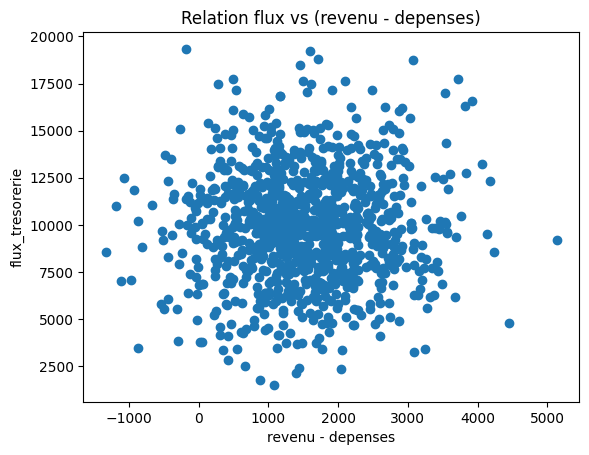

In [66]:
## Vérification graphique

plt.scatter(df["revenu"] - df["depenses"], df["flux_tresorerie"])
plt.xlabel("revenu - depenses")
plt.ylabel("flux_tresorerie")
plt.title("Relation flux vs (revenu - depenses)")
plt.show()

In [67]:
## Corrélation entre les 2
corr = np.corrcoef(df["flux_tresorerie"], df["revenu"] - df["depenses"])[0,1]
print("Corrélation :", corr)

Corrélation : 0.0415452777945875


### Commmentaire
Le verdict est sans appel : il est clair que le flux de trésorerie d'une agence bancaire n’est PAS expliqué par le revenu et les dépenses”.
L'on obtient : Erreur moyenne >>> 0 ; un nuage de points beaucoup trop dispersé ; et une très faible corrélation entre les autres variables.
D'où ce modèle ne peut pas apprendre, donc inutile de l’entraîner. Nous venons de prouver que ce dataset est non prédictif dans sa forme actuelle.
Il nous faudra d’abord corriger les données. Vu qu'il nous est impossible d'ajouter des variables pertinentes manquantes (délais de paiement, dettes, investissements, flux passés, ...), nous allons procéder à la reconstruction du dataset initial pour obtenir une target qui est fonction des autres variables.


## Features Engineering - Création des Features Optimales

In [68]:
## Nouvelles variables

df["marge"] = (df["revenu"] - df["depenses"]) / (df["revenu"] + 1)
df["ratio_dep_rev"] = df["depenses"] / (df["revenu"] + 1)
df["charge_interet"] = df["taux_interet"] * df["capital"]

print(df.columns)

Index(['bilan_financier', 'actifs', 'revenu', 'depenses', 'taux_interet',
       'flux_tresorerie', 'capital', 'agence', 'banque', 'lieu', 'diff',
       'marge', 'ratio_dep_rev', 'charge_interet'],
      dtype='str')


In [69]:
df = df.drop("diff", axis=1)

In [70]:
df.head(5)

,bilan_financier,actifs,revenu,depenses,taux_interet,flux_tresorerie,capital,agence,banque,lieu,marge,ratio_dep_rev,charge_interet
0,57450.712295,29795.488056,2459.857380,546.096221,4.850180,9549.649146,36581.956747,Agence_Centre,Société Générale,Bafoussam,0.777681,0.221913,177429.070412
1,47926.035482,26472.435780,2884.385063,1069.807495,0.854030,6207.981496,38725.670920,Agence_Centre,UBA,Douala,0.628886,0.370768,33072.896416
2,59715.328072,20417.412589,2366.064063,1293.197233,9.724614,11458.554375,77179.593209,Agence_Sud,UBA,Bafoussam,0.453248,0.546330,750541.744937
3,72845.447846,15471.442556,2753.630776,2443.843829,5.180104,4151.884734,36901.898344,Agence_Centre,UBA,Douala,0.112460,0.887177,191155.682796
4,46487.699379,24887.563195,1485.108266,1778.276562,6.141862,3848.927628,46121.492335,Agence_Centre,Ecobank,Bafoussam,-0.197273,1.196600,283271.861596


## Revalidation complète du modèle

In [71]:
# 1. X / y
X = df.drop("flux_tresorerie", axis=1)
y = df["flux_tresorerie"]

# 2. encoding
X = pd.get_dummies(X, drop_first=True)

# 3. split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [72]:
## Test corrélation

df_train = X_train.copy()
df_train["flux_tresorerie"] = y_train

print(df_train.corr()["flux_tresorerie"].sort_values())

depenses                  -0.049012
bilan_financier           -0.039879
ratio_dep_rev             -0.029790
lieu_Yaoundé              -0.028916
banque_Ecobank            -0.021813
lieu_Douala               -0.017598
actifs                    -0.002158
revenu                    -0.001348
charge_interet             0.012982
agence_Agence_Sud          0.019951
banque_UBA                 0.021597
taux_interet               0.023115
capital                    0.027281
marge                      0.029783
agence_Agence_Nord         0.035313
banque_Société Générale    0.044514
lieu_Garoua                0.045125
flux_tresorerie            1.000000
Name: flux_tresorerie, dtype: float64


In [73]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)  ## apprendre et transformer le training set
X_test = sc.transform(X_test) 

In [74]:
# Reconversion en dataframes (devenus array suite à la précédente transformation de sklearn)

X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

In [75]:
df.columns

Index(['bilan_financier', 'actifs', 'revenu', 'depenses', 'taux_interet',
       'flux_tresorerie', 'capital', 'agence', 'banque', 'lieu', 'marge',
       'ratio_dep_rev', 'charge_interet'],
      dtype='str')

In [76]:
cols_num = [
    "bilan_financier",
    "actifs",
    "revenu",
    "depenses",
    "taux_interet",
    "capital",
    'marge',
    'ratio_dep_rev',
    'charge_interet'
]
cols_num

['bilan_financier',
 'actifs',
 'revenu',
 'depenses',
 'taux_interet',
 'capital',
 'marge',
 'ratio_dep_rev',
 'charge_interet']

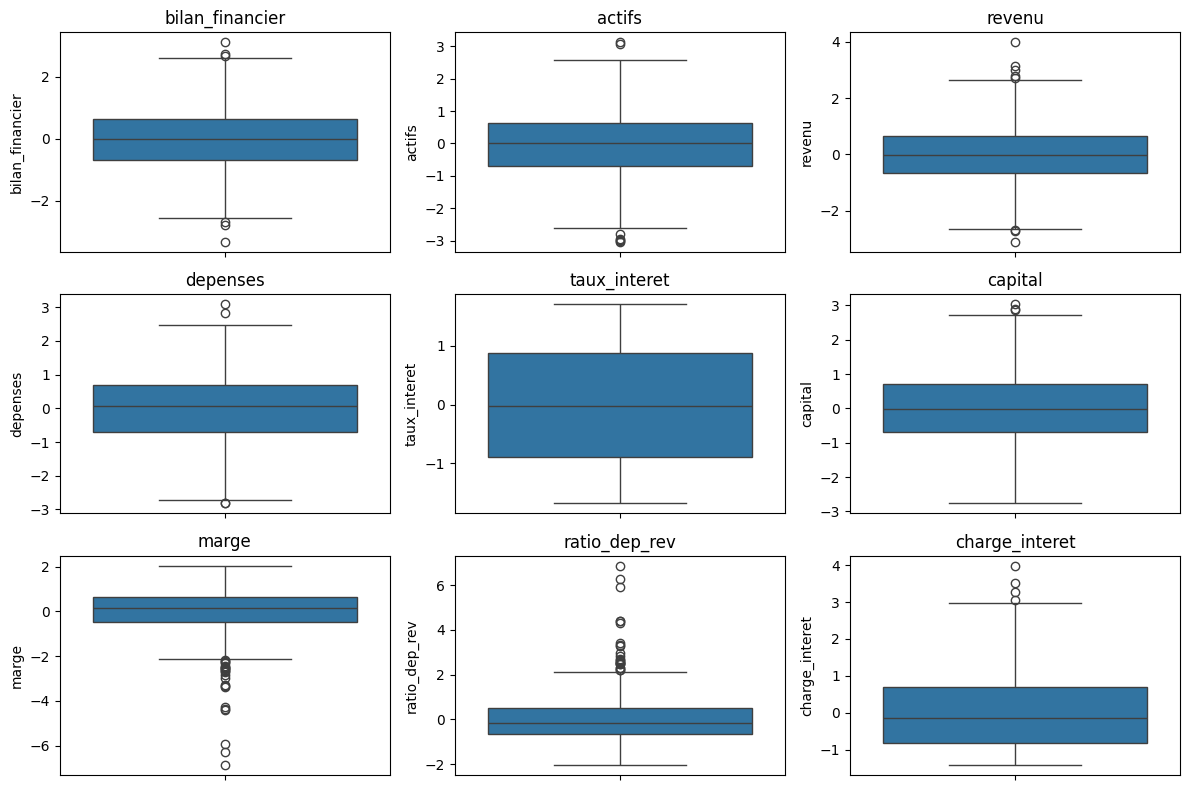

In [77]:
## Boxplots

plt.figure(figsize=(12, 8))

for i, col in enumerate(cols_num, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=X_train[col])
    plt.title(col)

plt.tight_layout()  ## optimiser les espacements automatiquement
plt.show()

In [78]:
X_train_num = X_train[cols_num]
X_train_num

,bilan_financier,actifs,revenu,depenses,taux_interet,capital,marge,ratio_dep_rev,charge_interet
0,-0.323727,-1.113351,-0.523756,0.059241,0.270471,1.200834,-0.201057,0.201027,0.834472
1,0.022387,-1.687893,-0.323122,1.575846,1.339233,0.148824,-1.178536,1.178895,1.225724
2,-0.341949,1.862002,1.439240,-0.280564,-1.470866,1.321060,0.812472,-0.812258,-1.160778
3,-0.467508,-0.892726,-0.018449,0.145412,-1.388739,-0.964555,0.042351,-0.042258,-1.250406
4,1.556611,-1.234841,1.921842,1.228983,-0.948167,-1.478218,0.245164,-0.244694,-1.094944
...,...,...,...,...,...,...,...,...,...
795,1.899247,0.529743,-0.941246,-1.231411,0.136542,-0.026885,0.613686,-0.614184,0.089586
796,1.445123,1.010482,0.333012,-0.183910,-1.388833,0.215622,0.416656,-0.416569,-1.154109
797,0.181132,-0.220778,-0.564157,-0.413619,-0.853250,-0.486982,0.141462,-0.141617,-0.832399
798,0.049636,0.198030,-0.399107,0.890064,-0.598966,-0.570854,-0.738566,0.738757,-0.676626


In [79]:
for col in X_train_num.columns:
    
    Q1 = X_train_num[col].quantile(0.25)
    Q3 = X_train_num[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    
    nb_outliers = ((X_train_num[col] < borne_inf) | (X_train_num[col] > borne_sup)).sum()
    
    print(f"{col} : {nb_outliers} outliers détectés")

bilan_financier : 6 outliers détectés
actifs : 7 outliers détectés
revenu : 8 outliers détectés
depenses : 4 outliers détectés
taux_interet : 0 outliers détectés
capital : 3 outliers détectés
marge : 23 outliers détectés
ratio_dep_rev : 23 outliers détectés
charge_interet : 4 outliers détectés


In [80]:
## Copie des données par sécurité (garder les données brutes intactes)

X_train_wins = X_train.copy()
X_test_wins = X_test.copy()

In [81]:
## Winsorisation

for col in cols_num:
    
    # Calcul sur X_train
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR

    # Fit sur le TRAIN
    X_train_wins[col] = np.where(X_train_wins[col] < borne_inf, borne_inf, X_train_wins[col])
    X_train_wins[col] = np.where(X_train_wins[col] > borne_sup, borne_sup, X_train_wins[col])

    # Fit sur le TEST
    X_test_wins[col] = np.where(X_test_wins[col] < borne_inf, borne_inf, X_test_wins[col])
    X_test_wins[col] = np.where(X_test_wins[col] > borne_sup, borne_sup, X_test_wins[col])

In [82]:
## Vérification imputation des outliers

for col in cols_num:
    
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR

    # AVANT
    nb_inf = (X_train[col] < borne_inf).sum()
    nb_sup = (X_train[col] > borne_sup).sum()

    # APRÈS
    nb_inf_w = (X_train_wins[col] < borne_inf).sum()
    nb_sup_w = (X_train_wins[col] > borne_sup).sum()

    print(f"{col} → AVANT: bas={nb_inf}, haut={nb_sup} | APRÈS: bas={nb_inf_w}, haut={nb_sup_w}")

bilan_financier → AVANT: bas=3, haut=3 | APRÈS: bas=0, haut=0
actifs → AVANT: bas=5, haut=2 | APRÈS: bas=0, haut=0
revenu → AVANT: bas=3, haut=5 | APRÈS: bas=0, haut=0
depenses → AVANT: bas=2, haut=2 | APRÈS: bas=0, haut=0
taux_interet → AVANT: bas=0, haut=0 | APRÈS: bas=0, haut=0
capital → AVANT: bas=0, haut=3 | APRÈS: bas=0, haut=0
marge → AVANT: bas=23, haut=0 | APRÈS: bas=0, haut=0
ratio_dep_rev → AVANT: bas=0, haut=23 | APRÈS: bas=0, haut=0
charge_interet → AVANT: bas=0, haut=4 | APRÈS: bas=0, haut=0


In [83]:
## Modélisation pour regression avec Random Forest 

rf = RandomForestRegressor(random_state=42)

In [84]:
## Définition des hyperparamètres à tester

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"]
}

In [85]:
## Vérification des variables conteneues dans le set d'entraînement
X_train_wins.head(5)

,bilan_financier,actifs,revenu,depenses,taux_interet,capital,marge,ratio_dep_rev,charge_interet,agence_Agence_Nord,agence_Agence_Sud,banque_Ecobank,banque_Société Générale,banque_UBA,lieu_Douala,lieu_Garoua,lieu_Yaoundé
0,-0.323727,-1.113351,-0.523756,0.059241,0.270471,1.200834,-0.201057,0.201027,0.834472,-0.739857,-0.719741,-0.565802,1.785632,-0.598527,-0.579275,-0.569652,1.732051
1,0.022387,-1.687893,-0.323122,1.575846,1.339233,0.148824,-1.178536,1.178895,1.225724,1.351612,-0.719741,-0.565802,1.785632,-0.598527,-0.579275,-0.569652,-0.577350
2,-0.341949,1.862002,1.439240,-0.280564,-1.470866,1.321060,0.812472,-0.812258,-1.160778,1.351612,-0.719741,1.767402,-0.560026,-0.598527,-0.579275,1.755458,-0.577350
3,-0.467508,-0.892726,-0.018449,0.145412,-1.388739,-0.964555,0.042351,-0.042258,-1.250406,-0.739857,-0.719741,-0.565802,1.785632,-0.598527,-0.579275,1.755458,-0.577350
4,1.556611,-1.234841,1.921842,1.228983,-0.948167,-1.478218,0.245164,-0.244694,-1.094944,-0.739857,-0.719741,-0.565802,-0.560026,1.670769,-0.579275,1.755458,-0.577350


In [86]:
## Recherche des hyperperamètres optimaux

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                 # 5 semi-échantillons pour la cross-validation
    scoring="r2",         # métrique principale
    n_jobs=-1,            # utilise tous les CPU
    verbose=1
)
## Training proprement dit
grid.fit(X_train_wins, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and 

In [87]:
## Meilleur modèle
best_model = grid.best_estimator_
print("Meilleurs paramètres :", grid.best_params_)

## Meilleur score de Validation Croisée
print("Score CV moyen :", grid.best_score_)

Meilleurs paramètres : {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Score CV moyen : -0.022592923455300708


In [88]:
## Prédictions

y_train_pred = best_model.predict(X_train_wins)
y_test_pred = best_model.predict(X_test_wins)

In [89]:
## Evaluation performances

print("TRAIN RMSE :", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("TRAIN R² :", r2_score(y_train, y_train_pred))

print("TEST RMSE :", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("TEST R² :", r2_score(y_test, y_test_pred))

TRAIN RMSE : 2856.7603198886814
TRAIN R² : 0.06929214321699828
TEST RMSE : 2959.981421143467
TEST R² : 0.0048467801071623295


In [90]:
# Top 5 des variables les plus importantes dans la construction de ce modèle

importance = pd.DataFrame({
    "Variable": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance.head(5)

,Variable,Importance
8,charge_interet,0.153625
3,depenses,0.138542
1,actifs,0.109547
5,capital,0.103869
6,marge,0.103769


In [91]:
## Affichage des cohérences entre variables du training set  -- Test de corrélation --

df_train = X_train_wins.copy()
df_train["flux_tresorerie"] = y_train

df_train.corr()["flux_tresorerie"].sort_values()

bilan_financier           -0.057512
lieu_Garoua               -0.043109
actifs                    -0.040784
revenu                    -0.024405
banque_Société Générale   -0.010159
capital                   -0.007032
marge                     -0.006255
depenses                  -0.006045
banque_UBA                -0.002945
ratio_dep_rev              0.006250
lieu_Douala                0.007016
lieu_Yaoundé               0.013043
agence_Agence_Sud          0.022506
agence_Agence_Nord         0.024055
taux_interet               0.026704
charge_interet             0.027918
banque_Ecobank             0.044167
flux_tresorerie            1.000000
Name: flux_tresorerie, dtype: float64

## Interprêtation Finale

Tout ceci confirme que : même après nettoyage, winsorisation, feature engineering, Random Forest + GridSearch, le signal reste totalement absent dans nos données. Par conséquent, nous pouvons en conclure que : les variables disponibles ne permettent définitivement pas de prédire efficacement le flux de trésorerie (R² ≈ 0).

## Sauvegarde du modèle

In [93]:
import pickle

# sauvegarde des colonnes
cols = X_train_wins.columns

pickle.dump((best_model, cols), open("reg.pkl", "wb"))

In [94]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["banque", "agence", "lieu"])
], remainder="passthrough")

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", rf)
])